**Install dependencies**

In [8]:
!pip install scikit-learn tensorflow seaborn matplotlib yfinance vaderSentiment --quiet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
import tensorflow as tf

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Data Collection**

In [9]:
ticker = "RELIANCE.NS"

df = yf.download(
    ticker,
    start="2015-01-01",
    end="2025-01-01"
)

df.dropna(inplace=True)

df.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2015-01-01,189.999817,190.877171,189.090366,189.657446,2963643
2015-01-02,189.496918,191.743797,189.229441,190.042585,7331366
2015-01-05,187.421265,190.641790,187.046782,189.379255,10103941
2015-01-06,178.915222,186.811376,178.037869,186.169417,18627980
2015-01-07,182.809830,183.772776,179.107845,179.129243,20720312


**News Headlines Dataset**

In [11]:
import pandas as pd

news_data = pd.DataFrame({

    "Date": pd.date_range(
        start="2024-01-01",
        periods=12,
        freq="ME"
    ),

    "Headline": [
        "Reliance reports strong quarterly profit growth",
        "Jio expands 5G services across India",
        "Reliance Retail revenue surges",
        "Oil to chemical segment faces pressure",
        "Reliance partners with global energy firms",
        "Green energy investment announced",
        "Reliance share price hits record high",
        "Petrochemical margins decline",
        "New telecom tariff plans launched",
        "Reliance acquires renewable startup",
        "Global crude volatility impacts margins",
        "Analysts upgrade Reliance outlook"
    ]
})

news_data.head()


,Date,Headline
0,2024-01-31,Reliance reports strong quarterly profit growth
1,2024-02-29,Jio expands 5G services across India
2,2024-03-31,Reliance Retail revenue surges
3,2024-04-30,Oil to chemical segment faces pressure
4,2024-05-31,Reliance partners with global energy firms


**Sentiment Analysis**

In [12]:
analyzer = SentimentIntensityAnalyzer()

news_data["Sentiment"] = news_data["Headline"].apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)

news_data.head()


,Date,Headline,Sentiment
0,2024-01-31,Reliance reports strong quarterly profit growth,0.8316
1,2024-02-29,Jio expands 5G services across India,0.1027
2,2024-03-31,Reliance Retail revenue surges,0.0000
3,2024-04-30,Oil to chemical segment faces pressure,-0.2960
4,2024-05-31,Reliance partners with global energy firms,0.2732


**Merge News with Stock Data**

In [13]:
df.columns = df.columns.droplevel(1)

df_sentiment = df.merge(
    news_data["Sentiment"],
    left_index=True,
    right_index=True,
    how="left"
)

df_sentiment["Sentiment"] = df_sentiment["Sentiment"].fillna(0)

df_sentiment.head()

,Close,High,Low,Open,Volume,Sentiment
Date,,,,,,
2015-01-01 00:00:00,189.999817,190.877171,189.090366,189.657446,2963643,0.0
2015-01-02 00:00:00,189.496918,191.743797,189.229441,190.042585,7331366,0.0
2015-01-05 00:00:00,187.421265,190.641790,187.046782,189.379255,10103941,0.0
2015-01-06 00:00:00,178.915222,186.811376,178.037869,186.169417,18627980,0.0
2015-01-07 00:00:00,182.809830,183.772776,179.107845,179.129243,20720312,0.0


**EDA Price Trend**

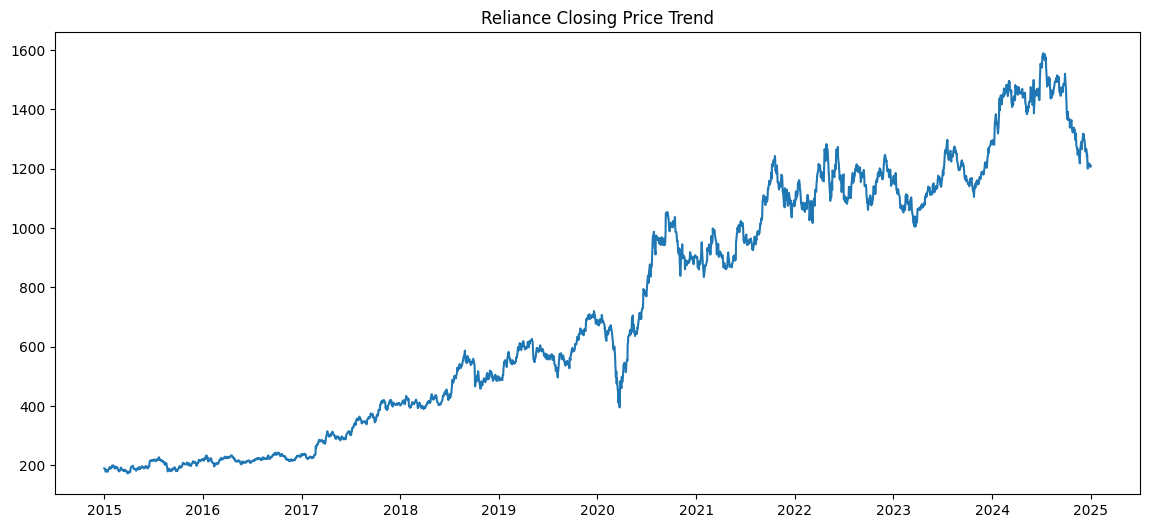

In [14]:
plt.figure(figsize=(14,6))
plt.plot(df_sentiment["Close"])
plt.title("Reliance Closing Price Trend")
plt.show()


**EDA** **Volume Analysis**

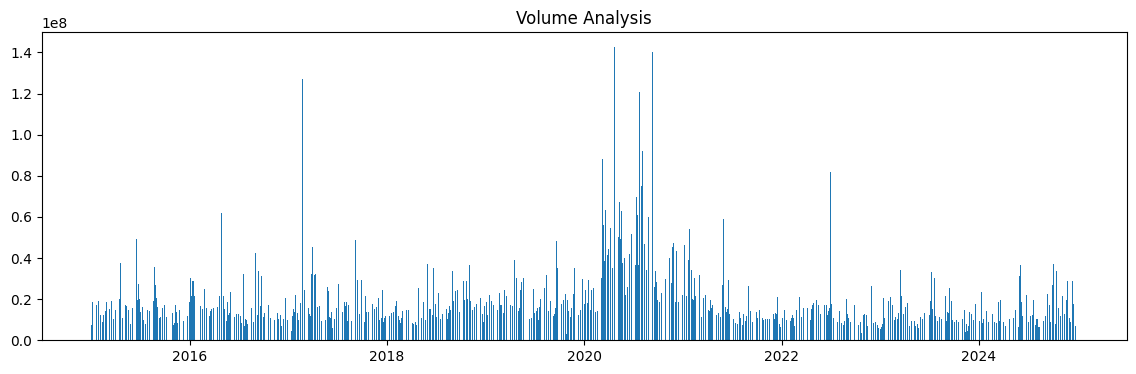

In [15]:
plt.figure(figsize=(14,4))
plt.bar(df_sentiment.index, df_sentiment["Volume"])
plt.title("Volume Analysis")
plt.show()


**EDA Moving Averages**

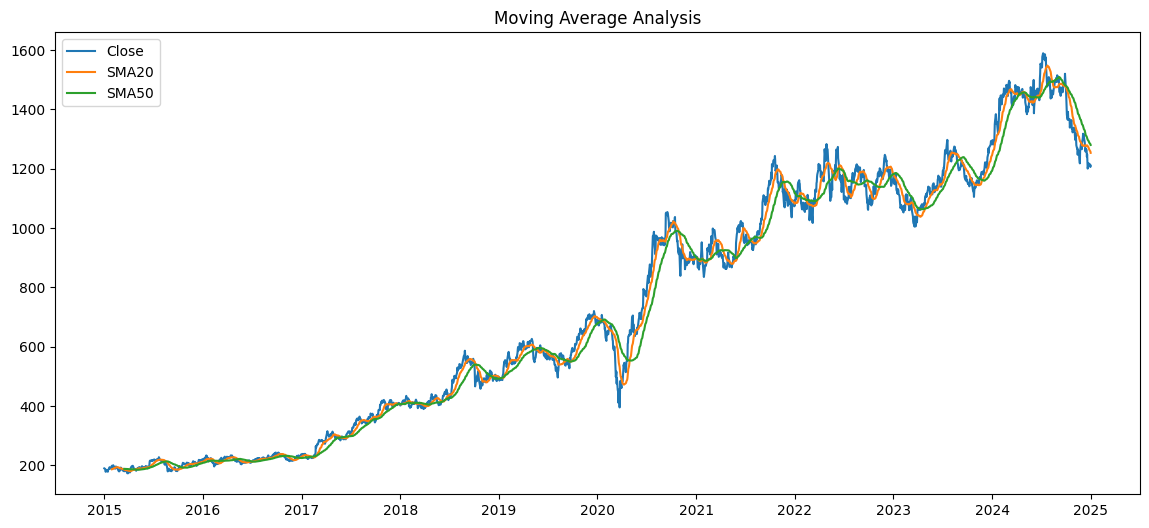

In [16]:
df_sentiment["SMA20"] = (
    df_sentiment["Close"].rolling(20).mean()
)

df_sentiment["SMA50"] = (
    df_sentiment["Close"].rolling(50).mean()
)

plt.figure(figsize=(14,6))

plt.plot(df_sentiment["Close"], label="Close")
plt.plot(df_sentiment["SMA20"], label="SMA20")
plt.plot(df_sentiment["SMA50"], label="SMA50")

plt.legend()
plt.title("Moving Average Analysis")
plt.show()


**EDA Correlation Heatmap**

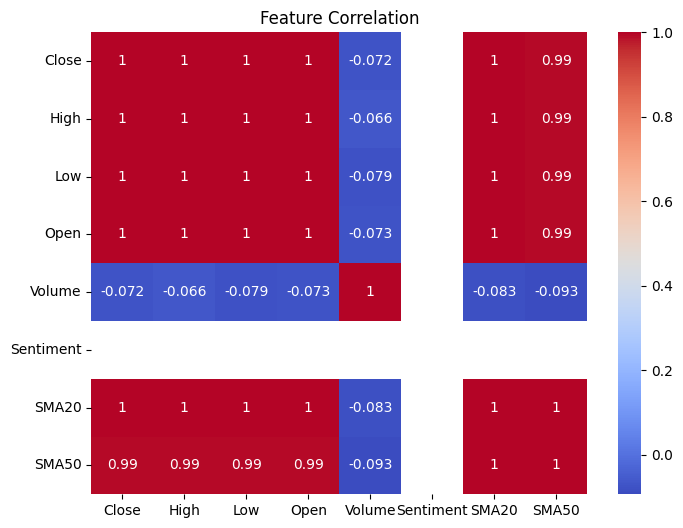

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df_sentiment.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")
plt.show()


**Feature Selection :** I include sentiment.

In [18]:
data = df_sentiment[
    ["Close", "Sentiment"]
]

data.dropna(inplace=True)


**Scaling**

In [19]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)


**Sequence Creation**

In [20]:
SEQ_LEN = 60

def create_sequences(data, seq_len):

    X, y = [], []

    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i, 0])  # Close price target

    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, SEQ_LEN)


**Train-Test Split**

In [21]:
train_size = int(len(X)*0.7)

X_train = X[:train_size]
X_test  = X[train_size:]

y_train = y[:train_size]
y_test  = y[train_size:]


**LSTM Model**

In [22]:
tf.keras.backend.clear_session()

lstm_model = Sequential()

lstm_model.add(tf.keras.Input(shape=(SEQ_LEN, 2)))
lstm_model.add(LSTM(
    64,
    return_sequences=True
))

lstm_model.add(Dropout(0.3))

lstm_model.add(LSTM(64))
lstm_model.add(Dropout(0.3))

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.0131 - val_loss: 0.0046
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0019 - val_loss: 0.0012
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0017 - val_loss: 7.4868e-04
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0016 - val_loss: 7.3252e-04
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0014 - val_loss: 0.0035
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0013 - val_loss: 0.0030
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0012 - val_loss: 0.0028
Epoch 9/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 10/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0012 - val_loss: 0.0020
Epoch 11/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0012 - val_loss: 0.0014
Epoch 12/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - 

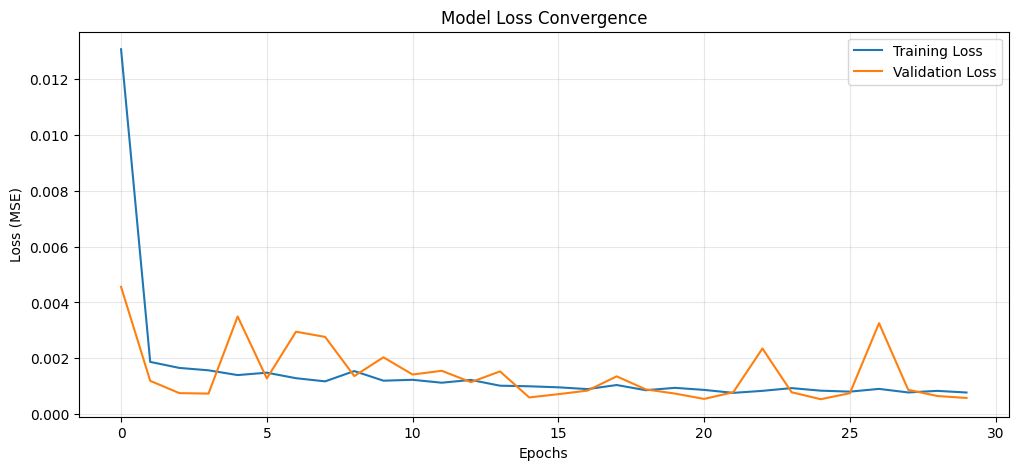

In [23]:
# ==== Loss Curve Visualization ====

plt.figure(figsize=(12,5))

plt.plot(history_lstm.history['loss'],
         label='Training Loss')

plt.plot(history_lstm.history['val_loss'],
         label='Validation Loss')

plt.title("Model Loss Convergence")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**LSTM Predictions**

In [24]:
lstm_pred_scaled = lstm_model.predict(X_test)

# Inverse scaling (Close only)
lstm_pred = scaler.inverse_transform(
    np.concatenate(
        [lstm_pred_scaled,
         np.zeros((len(lstm_pred_scaled),1))],
        axis=1
    )
)[:,0]

actual = scaler.inverse_transform(
    np.concatenate(
        [y_test.reshape(-1,1),
         np.zeros((len(y_test),1))],
        axis=1
    )
)[:,0]


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


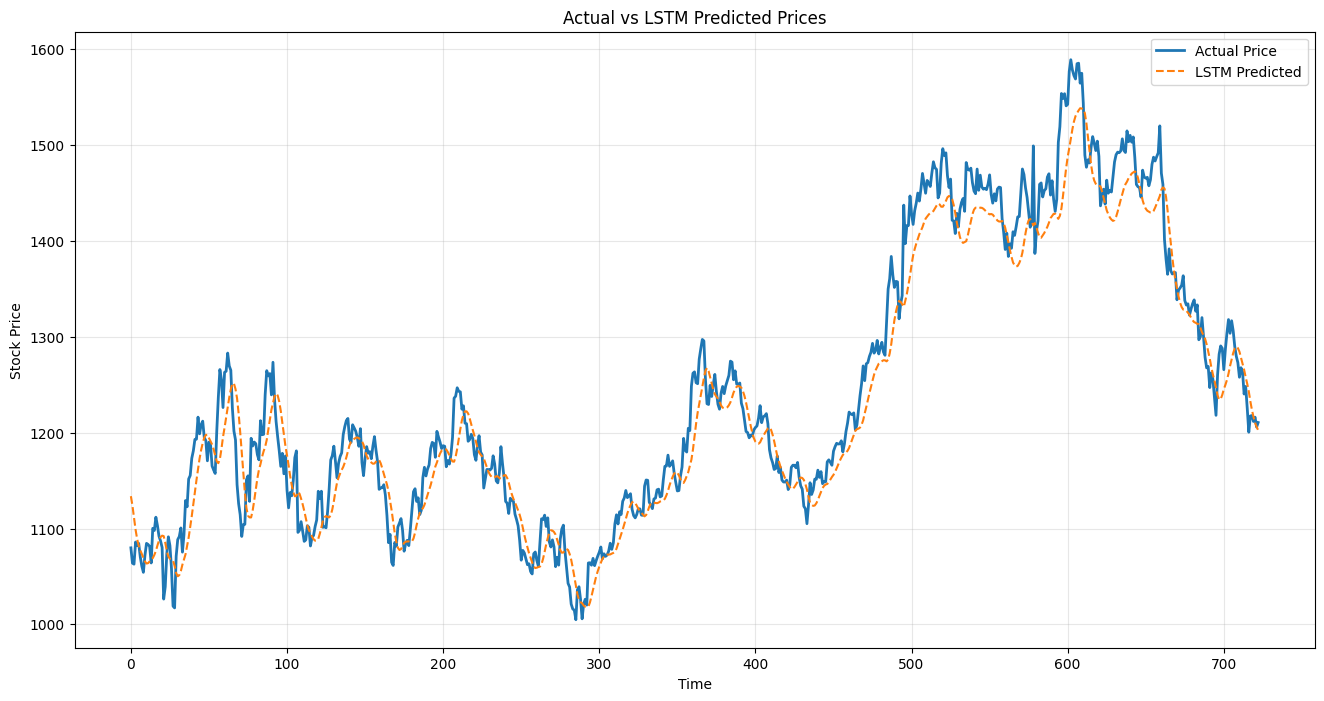

In [25]:
# ==== Actual vs LSTM Prediction ====

plt.figure(figsize=(16,8))

plt.plot(actual,
         label="Actual Price",
         linewidth=2)

plt.plot(lstm_pred,
         label="LSTM Predicted",
         linestyle="--")

plt.title("Actual vs LSTM Predicted Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [27]:
# ==== Date Alignment for LSTM ====

lstm_len = len(actual)

dates_lstm = df.index[-lstm_len:]

# ==== LSTM Table with Date ====

lstm_table = pd.DataFrame({

    "Date": dates_lstm,
    "Actual Price": actual.flatten(),
    "LSTM Predicted Price": lstm_pred.flatten()
})

# Error columns
lstm_table["Absolute Error"] = (
    lstm_table["Actual Price"] -
    lstm_table["LSTM Predicted Price"]
).abs()

lstm_table["% Error"] = (
    lstm_table["Absolute Error"] /
    lstm_table["Actual Price"]
) * 100

lstm_table.head()



,Date,Actual Price,LSTM Predicted Price,Absolute Error,% Error
0,2022-01-25,1079.857300,1133.753685,53.896385,4.991065
1,2022-01-27,1063.863647,1123.821414,59.957766,5.635851
2,2022-01-28,1062.839722,1111.502225,48.662503,4.578536
3,2022-01-31,1085.931763,1098.781897,12.850135,1.183328
4,2022-02-01,1082.337036,1089.135419,6.798382,0.628121


**Residual Extraction**

In [28]:
residuals = actual - lstm_pred


**Residual Scaling**

In [29]:
res_scaler = MinMaxScaler()

res_scaled = res_scaler.fit_transform(
    residuals.reshape(-1,1)
)


**Residual Sequences**

In [30]:
X_res, y_res = create_sequences(res_scaled, SEQ_LEN)

train_size_res = int(len(X_res)*0.8)

X_res_train = X_res[:train_size_res]
X_res_test  = X_res[train_size_res:]

y_res_train = y_res[:train_size_res]
y_res_test  = y_res[train_size_res:]


**GRU Residual Model**

In [31]:
tf.keras.backend.clear_session()

gru_model = Sequential()

gru_model.add(GRU(
    64,
    return_sequences=True,
    input_shape=(SEQ_LEN,1)
))

gru_model.add(Dropout(0.3))

gru_model.add(GRU(32))
gru_model.add(Dense(1))

gru_model.compile(
    optimizer="adam",
    loss="mse"
)

history_gru = gru_model.fit(
    X_res_train,
    y_res_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_res_test, y_res_test)
)

Epoch 1/20


C:\Users\suman\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 0.0598 - val_loss: 0.0177
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0174 - val_loss: 0.0167
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0148 - val_loss: 0.0164
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0132 - val_loss: 0.0154
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0133 - val_loss: 0.0147
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0124 - val_loss: 0.0141
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0124 - val_loss: 0.0140
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0115 - val_loss: 0.0130
Epoch 9/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0116 - val_loss: 0.0125
Epoch 10/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0108 - val_loss: 0.0119
Epoch 11/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0106 - val_loss: 0.0115
Epoch 12/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0104 - val_l

**Residual Prediction**

In [32]:
residual_pred_scaled = gru_model.predict(X_res_test)

residual_pred = res_scaler.inverse_transform(
    residual_pred_scaled
)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step


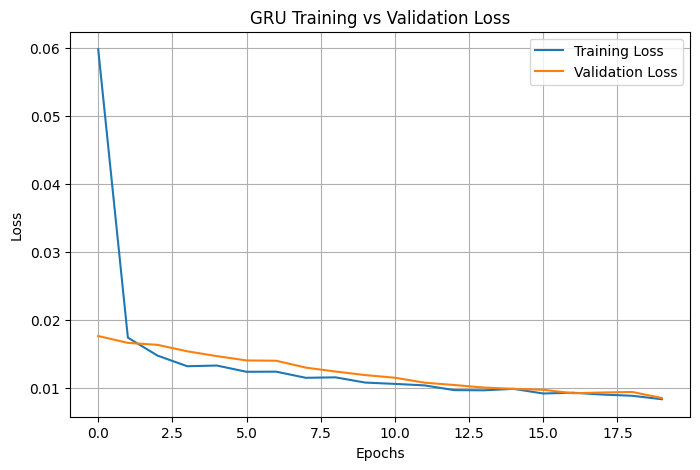

In [33]:
# ==== GRU Training Loss vs Validation Loss Visualization ====

import matplotlib.pyplot as plt



plt.figure(figsize=(8,5))

plt.plot(history_gru.history['loss'],
         label='Training Loss')

plt.plot(history_gru.history['val_loss'],
         label='Validation Loss')

plt.title('GRU Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

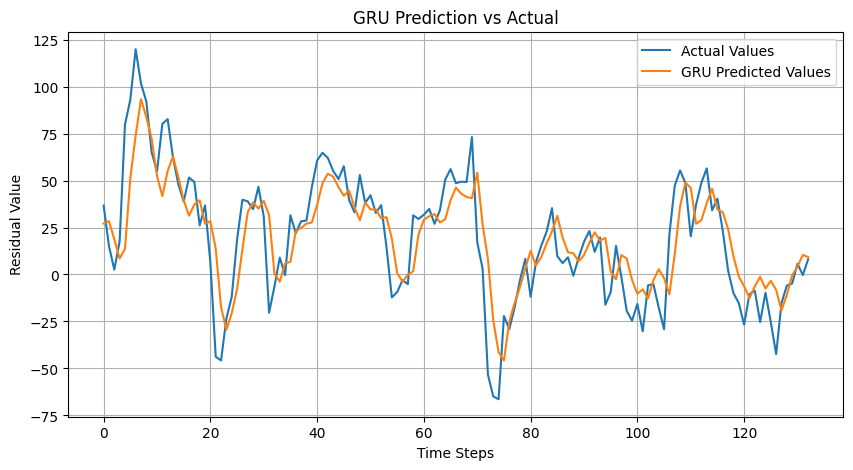

In [34]:
# ==== GRU Prediction vs Actual Visualization ====

import matplotlib.pyplot as plt
import numpy as np

# If predictions are scaled → inverse transform first
# (Skip this block if already inverse transformed)

gru_predicted = res_scaler.inverse_transform(residual_pred_scaled)
actual_values = res_scaler.inverse_transform(y_res_test.reshape(-1,1))


# ---- Plot ----
plt.figure(figsize=(10,5))

plt.plot(actual_values,
         label='Actual Values')

plt.plot(gru_predicted,
         label='GRU Predicted Values')

plt.title('GRU Prediction vs Actual')
plt.xlabel('Time Steps')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True)

plt.show()


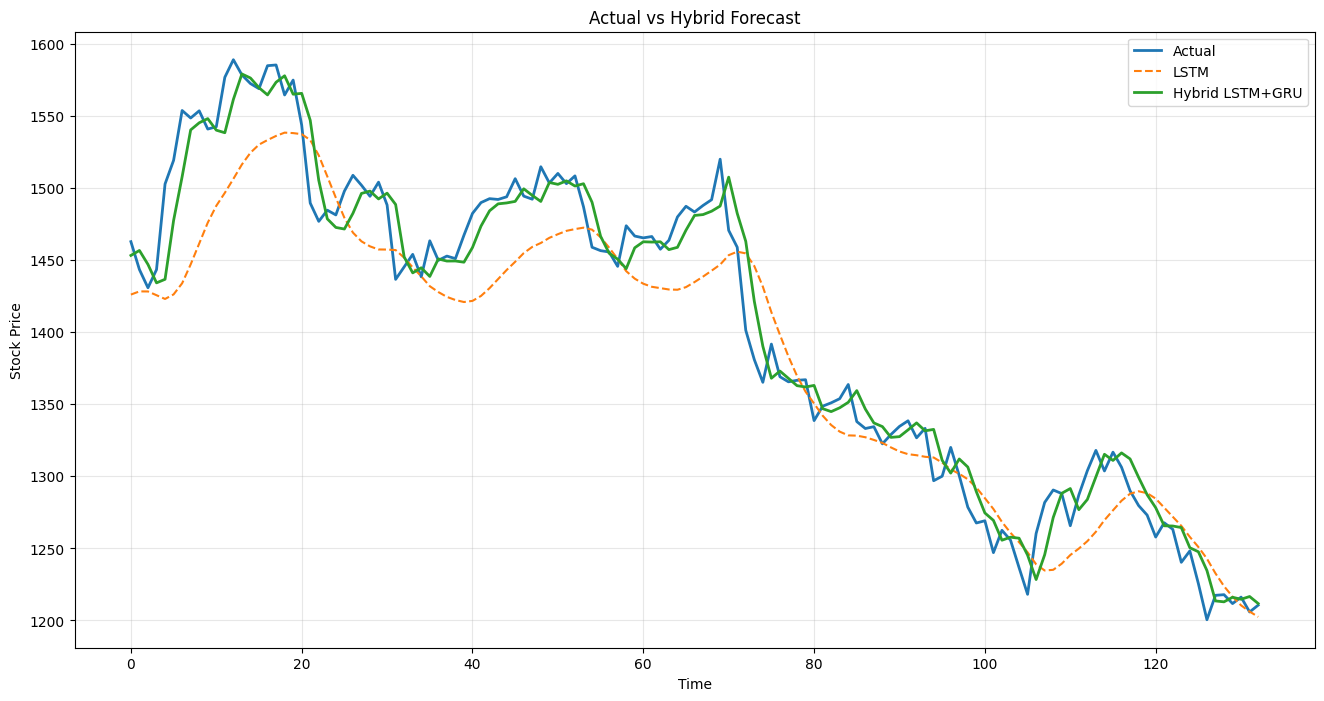

In [35]:
# ==== Hybrid Forecast Visualization ====

min_len = min(len(lstm_pred), len(residual_pred))

lstm_aligned = lstm_pred[-min_len:]
actual_aligned = actual[-min_len:]
residual_pred_aligned = residual_pred[-min_len:].flatten()

hybrid_pred = (
    lstm_aligned +
    residual_pred_aligned
)

plt.figure(figsize=(16,8))

plt.plot(actual_aligned,
         label="Actual",
         linewidth=2)

plt.plot(lstm_aligned,
         label="LSTM",
         linestyle="--")

plt.plot(hybrid_pred,
         label="Hybrid LSTM+GRU",
         linewidth=2)

plt.title("Actual vs Hybrid Forecast")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [36]:
hybrid_len = len(actual_aligned)

dates_hybrid = df.index[-hybrid_len:]

# ==== Hybrid Table with Date ====

hybrid_table = pd.DataFrame({

    "Date": dates_hybrid,
    "Actual Price": actual_aligned.flatten(),
    "LSTM Price": lstm_aligned.flatten(),
    "Hybrid Predicted Price": hybrid_pred.flatten()
})

# Error calculations
hybrid_table["LSTM Error"] = (
    hybrid_table["Actual Price"] -
    hybrid_table["LSTM Price"]
).abs()

hybrid_table["Hybrid Error"] = (
    hybrid_table["Actual Price"] -
    hybrid_table["Hybrid Predicted Price"]
).abs()

hybrid_table["Hybrid % Error"] = (
    hybrid_table["Hybrid Error"] /
    hybrid_table["Actual Price"]
) * 100

hybrid_table.head()


,Date,Actual Price,LSTM Price,Hybrid Predicted Price,LSTM Error,Hybrid Error,Hybrid % Error
0,2024-06-20,1462.872559,1426.150008,1453.313773,36.722551,9.558786,0.653426
1,2024-06-21,1443.515869,1428.369855,1456.761035,15.146014,13.245166,0.917563
2,2024-06-24,1430.884277,1428.306824,1447.061649,2.577454,16.177372,1.130586
3,2024-06-25,1443.466309,1425.739841,1434.280277,17.726468,9.186032,0.636387
4,2024-06-26,1502.901367,1423.109236,1436.757118,79.792131,66.144249,4.401104


**Alignment**

In [37]:
min_len = min(len(lstm_pred), len(residual_pred))

lstm_aligned = lstm_pred[-min_len:]
actual_aligned = actual[-min_len:]
residual_pred_aligned = residual_pred[-min_len:].flatten()


**Final Hybrid Forecast**

In [38]:
hybrid_pred = (
    lstm_aligned +
    residual_pred_aligned
)


**Optimization Metrics**

In [39]:
def evaluate(name, y_true, y_pred):

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true-y_pred)/y_true))*100

    print(name)
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("MAPE:", mape)
    print("-"*30)

evaluate("LSTM", actual_aligned, lstm_aligned)
evaluate("Hybrid LSTM+GRU", actual_aligned, hybrid_pred)


LSTM
MAE : 31.559496391056165
RMSE: 39.28012147663708
MAPE: 2.19189896569326
------------------------------
Hybrid LSTM+GRU
MAE : 14.710402262089525
RMSE: 19.819604095470364
MAPE: 1.0506571696186295
------------------------------


**Visualization**

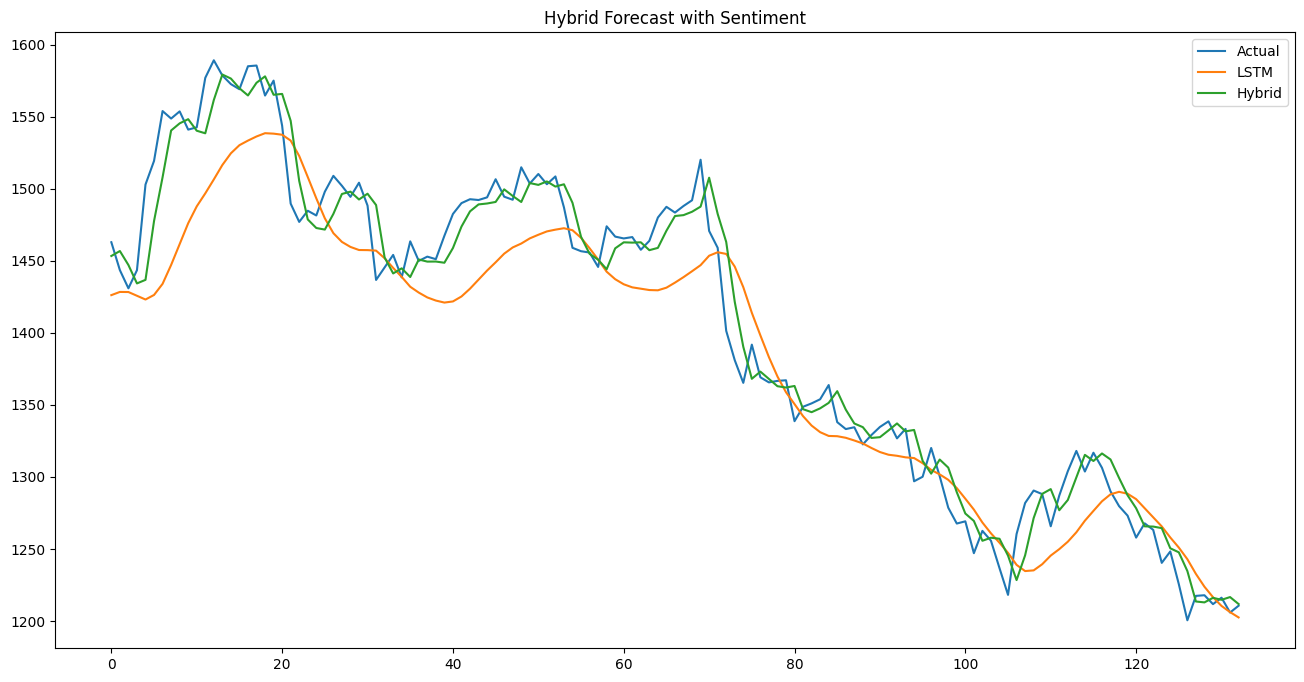

In [40]:
plt.figure(figsize=(16,8))

plt.plot(actual_aligned, label="Actual")
plt.plot(lstm_aligned, label="LSTM")
plt.plot(hybrid_pred, label="Hybrid")

plt.legend()
plt.title("Hybrid Forecast with Sentiment")
plt.show()
